# 01 — MNIST Linear Autoencoder

We train a **linear autoencoder** on MNIST and use its **latent codes** for unsupervised-style visualization: we scatter the latent space and color by ground-truth labels to see that the AE learns a representation that clusters by digit.

## Load packages and helpers

In [13]:
import torch
import numpy as np
from utils import (
    get_device,
    get_mnist_loaders,
    LinearAE,
    AETrainer,
    scatter_latent,
    plot_reconstructions,
)

## Load MNIST

In [14]:
train_loader, val_loader = get_mnist_loaders(root="./data", batch_size=32)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 1875, Val batches: 313


## Create model and trainer

In [15]:
device = get_device()
latent_dim = 32  # use 2 for direct 2D scatter; use 32 and let scatter_latent run t-SNE
model = LinearAE(latent_dim=latent_dim)
trainer = AETrainer(model, train_loader, val_loader, learning_rate=1e-3, device=device)

## Train

In [16]:
n_epochs = 4
trainer.run(n_epochs)

====> Epoch: 1 Train loss: 0.2209
====> Epoch: 1 Val loss: 0.1930


====> Epoch: 2 Train loss: 0.1869
====> Epoch: 2 Val loss: 0.1717


====> Epoch: 3 Train loss: 0.1652
====> Epoch: 3 Val loss: 0.1559


====> Epoch: 4 Train loss: 0.1516
====> Epoch: 4 Val loss: 0.1443


## Latent space clustering (colored by digit)

We encode the validation set and scatter the latent codes. If latent dim > 2, t-SNE is applied so we can visualize.

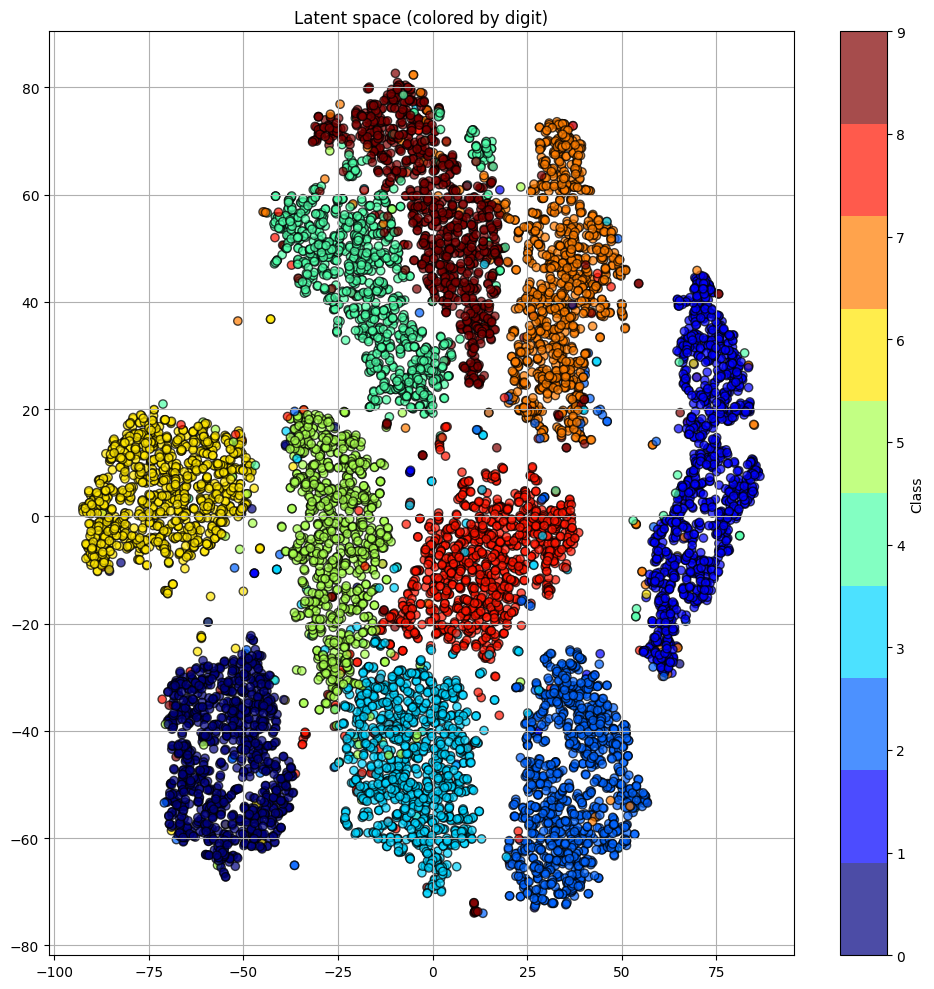

In [17]:
model.eval()
latents, labels_list = [], []
with torch.no_grad():
    for data, labels in val_loader:
        data = data.to(device).view(data.size(0), -1)
        z = model.encode(data)
        latents.append(z.cpu().numpy())
        labels_list.append(labels.numpy())
latents = np.concatenate(latents, axis=0)
labels_all = np.concatenate(labels_list, axis=0)
scatter_latent(latents, labels_all, use_tsne=True, title="Latent space (colored by digit)")

[7 2 1 ... 4 5 6]


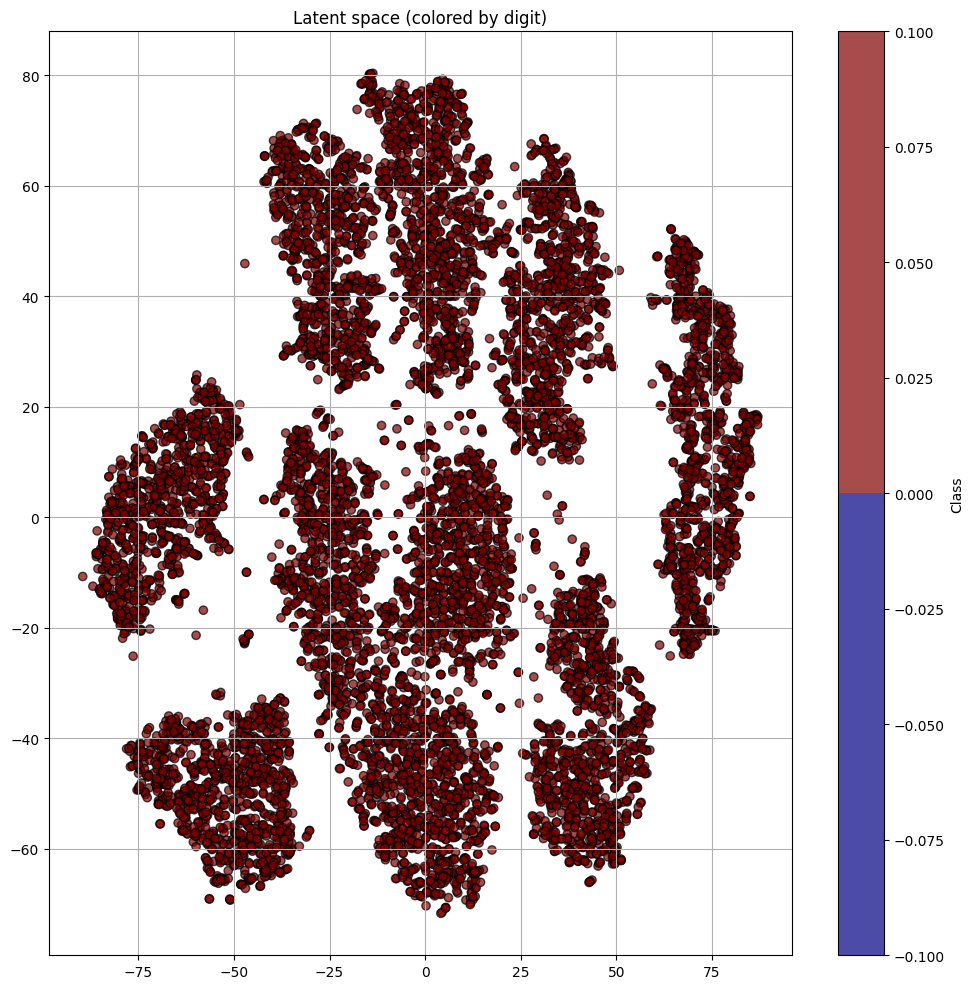

In [8]:
print(labels_all)
labels_all_x = labels_all.copy()
for i in range(len(labels_all_x)):
                labels_all_x[i] = 0
scatter_latent(latents, labels_all_x, use_tsne=True, title="Latent space (colored by digit)")

## Reconstructions

Original vs reconstructed images for a few validation samples.

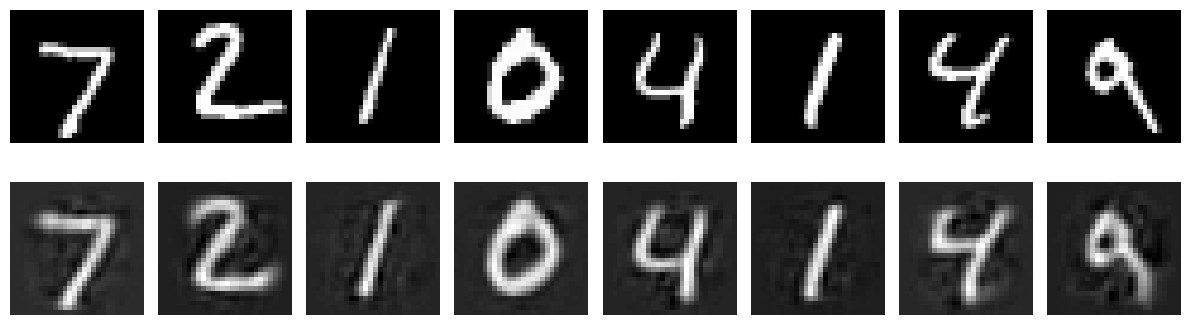

In [12]:
model.eval()
with torch.no_grad():
    data, _ = next(iter(val_loader))
    data = data.to(device).view(data.size(0), -1)
    recon = model(data)
    # z = model.encode(data)
    # recon = model.decode(z)
plot_reconstructions(data, recon, n=8)